# Singular Value Decomposition 

### Let $A$ be a $m \times n $ matrix 

### Then $A$ can be written as $A = U \Sigma V^T$, called its SVD decomposition 

- where $U \in \mathrm{R}^{m \times m}$ $V \in \mathrm{R}^{n \times n}$ are orthogonal matrices

- $\Sigma \in \mathrm{R}^{m \times n}$ is diagonal 

In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [43]:
A0 = np.random.rand(3,2)

In [44]:
A0

array([[0.12812836, 0.65611363],
       [0.19837881, 0.54203791],
       [0.30963604, 0.90005288]])

## the general pattern
- (a - b) * np.random.rand(m,n) + b
- where [a, b] is the interval in which random numbers are seeked

In [40]:
A = 2 * np.random.rand(3,2) - 1

In [42]:
A

array([[-0.19842066, -0.91909111],
       [ 0.74609888, -0.62211579],
       [ 0.50673753, -0.54676876]])

## Reduced SVD

In [45]:
U,S,Vh = np.linalg.svd(A, full_matrices=False)

- in the above $Vh = V^*$

- How do these U, S and Vh look like ?

In [46]:
U

array([[-0.51788471,  0.85037842],
       [-0.66851929, -0.47015983],
       [-0.53373906, -0.23623354]])

- therefore U is $m \times n$

In [47]:
S

array([1.35844736, 0.73358748])

- S is $n \times 1$

In [49]:
Vh

array([[-0.49062488,  0.87137089],
       [-0.87137089, -0.49062488]])

- Vh is $n \times n$

- We can verify that $A = U \Sigma V^*$ by computing the element-wise maximum difference

In [13]:
print(np.abs(A - U@np.diag(S)@Vh).max())

1.1102230246251565e-16


- The singular values and vectors are given as:
\begin{align}
u_j &= U[:,j],\ \qquad 0 \leq j <n \\
v_j &= Vh[j,:],\qquad 0 \leq j <n \\
\sigma_j &= S[j],\ \quad \qquad 0 \leq j <n
\end{align}

In [14]:
A_reconstructed = U @ np.diag(S) @ Vh

In [15]:
A_reconstructed

array([[ 0.61774931, -0.12433988],
       [-0.23948518,  0.53315992],
       [ 0.46694427, -0.82302982]])

## Full SVD

In [50]:
U,S,Vh = np.linalg.svd(A, full_matrices=True)

In [51]:
U

array([[-0.51788471,  0.85037842, -0.09301598],
       [-0.66851929, -0.47015983, -0.57622192],
       [-0.53373906, -0.23623354,  0.81198296]])

- therefore U is $m \times m$

In [20]:
S

array([1.19466276, 0.45484414])

- S is still $1 \times n$

In [22]:
Vh

array([[-0.60733037,  0.79444938],
       [-0.79444938, -0.60733037]])

- Vh is $n \times n$

- what happens if we try to reconstruct now 

In [23]:
A_reconstructed = U @ np.diag(S) @ Vh

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

- offcourse it doesn't go through as 
- The singular vectors and values are given by:
\begin{align}
u_j &= U[:,j],\ \qquad 0 \leq j <m \\
v_j &= Vh[j,:],\qquad 0 \leq j <n \\
\sigma_j &= S[j],\ \quad \qquad 0 \leq j <n
\end{align}


## Rank deficient case

Construct a random $4 \times 3 $ matrix whose last column is sum of first two columns. Its rank is 2.

In [24]:
A = 2 * np.random.rand(4,3) - 1
A[:,2] = A[:,0] + A[:,1]

- Compute the reduced SVD

In [25]:
U,S,Vh = np.linalg.svd(A, full_matrices=False)
print('U = \n', U)
print('sigma = ', *S)
print('V = \n', Vh.T)

U = 
 [[-0.56057031 -0.06144522  0.82014344]
 [ 0.49476292 -0.79861352  0.298237  ]
 [-0.65171555 -0.58138234 -0.48670277]
 [-0.12742616  0.1429528   0.03924085]]
sigma =  1.3776340080517193 0.8164720182902958 5.1977889105621405e-17
V = 
 [[ 0.10115187 -0.81020674  0.57735027]
 [ 0.65108369  0.49270346  0.57735027]
 [ 0.75223556 -0.31750328 -0.57735027]]


- notice that one out of three singular values is zero. 
- The number of non-zero singular values corresponds to the rank of the matrix.

## Random matrix

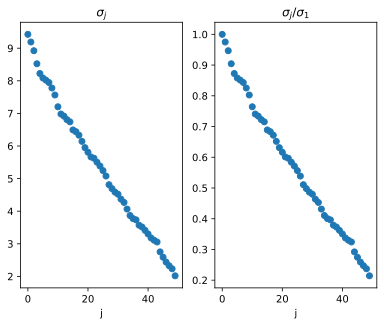

In [52]:
m, n = 100, 50
A = 2 * np.random.rand(m,n) - 1
U,S,Vh = np.linalg.svd(A, full_matrices=False)

plt.subplot(121)
plt.plot(S,'o')
plt.xlabel('j')
plt.title('$\\sigma_j$')

plt.subplot(122)
plt.plot(S/S[0],'o')
plt.xlabel('j')
plt.title('$\\sigma_j/\\sigma_1$');

- `plt.plot(S,'o')` plots $y=S[j]=\sigma_{j+1}$ against $x=j$
-  so the first point corresponds to $\sigma_1$
- `plt.subplot(121)` means 1 row, 2 columns, first plot i.e. subplot(1,2,1).
- `plt.subplot(122)` means 1 row, 2 columns, second plot i.e. subplot(1,2,2)

#### All singular values are of very similar size.

## Image compression using SVD

In [53]:
%config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt
from matplotlib.image import imread
import numpy as np
import os

[[[137 177 212]
  [136 176 211]
  [134 172 208]
  ...
  [134 176 216]
  [133 175 217]
  [130 172 214]]

 [[134 172 208]
  [134 172 208]
  [135 173 209]
  ...
  [134 176 216]
  [135 174 217]
  [130 172 214]]

 [[138 174 210]
  [140 176 212]
  [142 177 215]
  ...
  [135 174 215]
  [135 172 216]
  [132 171 214]]

 ...

 [[248 247 243]
  [248 247 243]
  [248 247 243]
  ...
  [210 215 221]
  [211 216 220]
  [212 217 221]]

 [[249 248 244]
  [248 247 243]
  [248 247 243]
  ...
  [209 214 220]
  [210 215 219]
  [211 216 220]]

 [[249 248 244]
  [248 247 243]
  [248 247 243]
  ...
  [210 215 221]
  [210 215 219]
  [211 216 220]]]


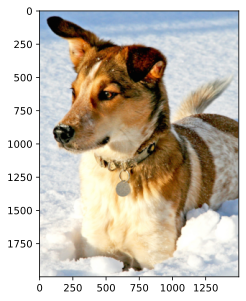

In [55]:
A = imread('dog.jpg')
print(A)
img = plt.imshow(A)

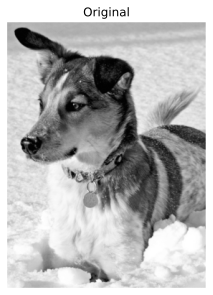

In [58]:
X = np.mean(A, -1); # Convert RGB to grayscale

img = plt.imshow(X)
img.set_cmap('gray')
plt.axis('off')
plt.title('Original')
plt.show()

- A = imread('dog.jpg') reads the image into a NumPy array
- for an RGB image, A has shape (height, width, 3), 
    containing the red, green, and blue channels.
- X = np.mean(A, -1) averages the 3 RGB values at each pixel, 
    producing a 2D grayscale image X with shape (height, width

- `img = plt.imshow(X)` creates a `Matplotlib image object` 
    and stores a reference to that `object` in the variable `img`.

- `img` is therefore not the image data X; 
    it is an `object` representing the displayed image, 
    with properties such as its colormap, color limits, transparency, etc.
        
- `img.set_cmap('gray')` calls the method set_cmap() belonging to the `img` object
    and changes its colormap to grayscale.

### Compute the reduced SVD

In [33]:
U, S, VT = np.linalg.svd(X,full_matrices=False)
m, n = X.shape
print("Original image = m x n = %d x %d" %  (m, n))

Original image = m x n = 2000 x 1500


- Plot the singular values $\sigma_j$ their cumulative sums
      $\sum_{k=0}^{j-1} \sigma_k$

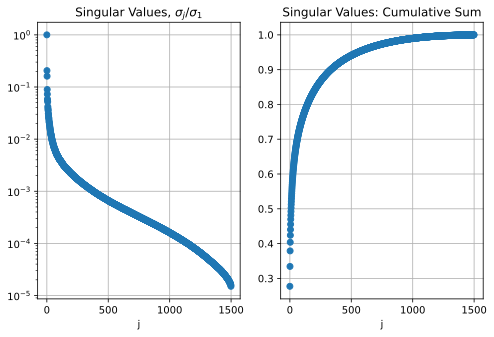

In [35]:
plt.figure(figsize=(8,5))

plt.subplot(1,2,1)
plt.semilogy(S/S[0],'o')
plt.title('Singular Values, $\\sigma_j/\\sigma_1$')
plt.xlabel('j')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(np.cumsum(S)/np.sum(S),'o')
plt.title('Singular Values: Cumulative Sum')
plt.xlabel('j')
plt.grid(True)

plt.show()

- The singular values decrease very rapidly, 
    only the first few are significant compared to the largest one.

### Low rank approximations

For given integer $r$, form

$X_r = U_r \Sigma_r V_r^T$

$U_r=
\begin{bmatrix}
| & | & & |\\
\mathbf{u}_1 & \mathbf{u}_2 & \cdots & \mathbf{u}_r\\
| & | & & |
\end{bmatrix}$, $\qquad$ $\Sigma_r = \mbox{diag}[\sigma_1, \sigma_2, \ldots, \sigma_r]$,
$\qquad$ $V_r=
\begin{bmatrix}
| & | & & |\\
\mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_r\\
| & | & & |
\end{bmatrix}$

-  $X_r$ requires us to store $r(1+m+n)$
 numbers, while full image requires $mn$
 numbers.

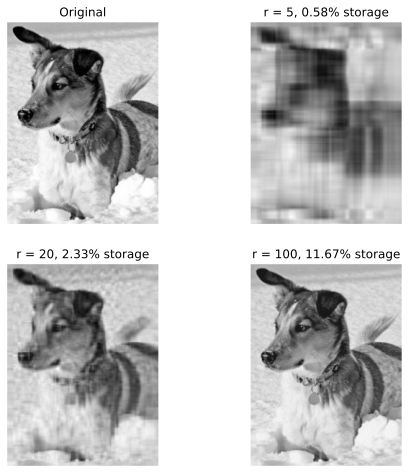

In [37]:
plt.figure(figsize=(8,8))

# Plot original image
j = 0
plt.subplot(2,2,j+1); j += 1
img = plt.imshow(X)
img.set_cmap('gray')
plt.axis('off')
plt.title('Original')

for r in (5, 20, 100):
    # Construct approximate image
    Xapprox = U[:,:r] @ np.diag(S[0:r]) @ VT[:r,:]
    plt.subplot(2,2,j+1); j += 1
    img = plt.imshow(Xapprox)
    img.set_cmap('gray')
    plt.axis('off')
    s = round((r*(1 + m + n))/(m*n) * 100, 2)
    plt.title('r = ' + str(r)+', '+str(s)+'% storage')
plt.show()

- The rank 100 approximation gives an image almost indistinguishable from the original and requires only about 12% of storage.

- `Xapprox = U[:,:r] @ np.diag(S[0:r]) @ VT[:r,:]` — keeps the first \(r\) singular components and reconstructs a rank-\(r\) approximation of the image.